In [1]:
import scanpy as sc
import os 
import scvi
import seaborn as sns
import torch
from rich import print
import numpy as np

adata = sc.read_h5ad("/data7/mark/STG/dataset/snRNA/merge_SCH_new/six_datasets_4v3_500_1000gene/TH_downsampled_ratio.h5ad")
adata.obs["celltype.L2"].value_counts()
#adata_subset = adata[adata.obs["celltype.L2"].isin(["TH Tll1_Thsd7b Glut"])]
# 选择第二最多的细胞
adata_subset = adata[adata.obs["celltype.L2"].isin(adata.obs["celltype.L2"].value_counts().head(2).index[1:2])]
# z只选male
adata_subset = adata_subset[adata_subset.obs["sex"] == "M"]
#去掉名字包含MW22B的样本
#adata_subset = adata_subset[~adata_subset.obs["sample"].str.contains("MW22B")]

/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata.obs["celltype.L2"].value_counts()


celltype.L2
MOL-1                      23858
Astrocyte-1                21068
TH Tll1_Thsd7b Glut        19158
MOL-2                      18150
TH Tnc_Cdh20 Glut          16458
TH Car4_Tspan11 Glut       15618
TH Cald1_Gm39185 Glut      12666
TH Fam20a_Fbln1 Glut       12130
TH Kcnk13_Nox4 Glut         8049
OPC                         7460
TH Ccdc192_Gli3 Glut        7451
TH Meis2_Gm2115 GABA        6763
TH Fgf10_Gm16263 Glut       4859
TH Parm1_Mdga1 Glut         4618
MOL-3                       4239
TH Egflam_Fbn2 Glut         3528
TH Tac2_Pde11a Glut         2643
Astrocyte-3                 2281
TH Col27a1_Npsr1 Glut       2077
MFOL                        2015
Astrocyte-4                 1299
Microglia-1                 1095
COP                          909
Endothelial cell             702
Choroid plexus cell          590
Ependymal cell               589
Microglia-2                  584
VLMC                         308
NFOL                         180
Pericyte                     15

In [3]:
# === 3. 数据结构探索（SCVI setup 前置） ===
print(f"shape: {adata_subset.shape}")
print(f"X dtype : {adata_subset.X.dtype}   X range: [{adata_subset.X.min()}, {adata_subset.X.max()}]")
print(f"layers  : {[k for k in adata_subset.layers.keys() if k is not None]}")

# 关键列 value counts —— 与 RUVDEG 一致的元信息
for col in ["status", "company", "celltype.L2", "sex", "sample", "region"]:
    if col in adata_subset.obs.columns:
        vc = adata_subset.obs[col].value_counts()
        print(f"\n{col} (n_unique={vc.size}):")
        print(vc.head(10))


shape: (13885, 16428)

X dtype : float32   X range: [0.0, 1900.0]

layers  : ['counts']

status (n_unique=5):

status
CSRES    3407
CUSUS    3049
CSSUS    2948
CON      2317
CURES    2164
Name: count, dtype: int64

...

sex
M    13885
Name: count, dtype: int64

sample (n_unique=17):

sample
MC25B_TH_yunzhun      1748
CSRS1-3_TH_beirui     1206
CS2-1_TH_beirui       1201
CSRS9-1_TH_beirui     1109
CSRS10-3_TH_beirui    1092
CS1-1_TH_beirui       1033
MW45A_TH_beirui        964
MC50E_TH_beirui        917
MC52B_TH_beirui        795
CS7-3_TH_beirui        714
Name: count, dtype: int64

region (n_unique=1):

region
TH    13885
Name: count, dtype: int64

In [4]:
adata_subset.obs.status.value_counts()

status
CSRES    3407
CUSUS    3049
CSSUS    2948
CON      2317
CURES    2164
Name: count, dtype: int64

In [5]:
adata_subset.layers["counts"]

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 21352213 stored elements and shape (13885, 16428)>

In [6]:
# === 5. n_genes_on 协变量（mirror RUVDEG cell 4） ===
# 用 raw counts 计算每个细胞 >0 的基因数，标准化后作为连续 nuisance covariate。
# 与 RUVDEG 完全一致：mean/std 由本次数据估计，z-score 后写入 adata.obs["n_genes_on"]。
n_genes_on_raw = (adata_subset.layers["counts"] > 0).sum(axis=1).astype(np.float32)
n_genes_on_mean = float(n_genes_on_raw.mean())
n_genes_on_std  = float(n_genes_on_raw.std())
if n_genes_on_std < 1e-8:
    raise ValueError("n_genes_on 没有足够变异，无法作为连续协变量")

adata_subset.obs["n_genes_on"] = (
    (n_genes_on_raw - n_genes_on_mean) / n_genes_on_std
).astype(np.float32)

print(f"raw mean / std    : {n_genes_on_mean:.1f} / {n_genes_on_std:.1f}")
print(f"standardized range: [{adata_subset.obs['n_genes_on'].min():.3f}, "
      f"{adata_subset.obs['n_genes_on'].max():.3f}]")


/tmp/ipykernel_3983748/1198264137.py:10: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_subset.obs["n_genes_on"] = (


raw mean / std    : 1537.8 / 451.2

standardized range: [-1.996, 5.570]

In [7]:
adata_subset.X = adata_subset.layers["counts"].copy()

In [8]:
# === 6. SCVI setup_anndata（mirror RUVDEG covariate 设计） ===
#
# RUVDEG → SCVI 映射：
#   batch (技术)         -> batch_key="company"
#   n_genes_on (连续)    -> continuous_covariate_keys=["n_genes_on"]
#   group (生物学 status) -> NOT 注册：SCVI 无监督，biology 体现在 latent z；
#                              保留在 adata.obs["status"] 供下游 DEG 使用。
# 不传 labels_key：本数据只含单个 L2 细胞类型，且 labels_key 语义上是细胞类型标签、
# 不是 biology-of-interest，作 covariate-as-label 会语义错误。

BATCH_KEY = "company"
CONT_COVS = ["n_genes_on"]

scvi.model.SCVI.setup_anndata(
    adata_subset,
    layer=None,                              # raw counts 在 adata.X
    batch_key=BATCH_KEY,                     # technical nuisance (RUVDEG `batch`)
    labels_key=None,                         # no cell-type label here
    categorical_covariate_keys=None,         # no extra categorical nuisance
    continuous_covariate_keys=CONT_COVS,     # technical continuous nuisance (RUVDEG `n_genes_on`)
)
print(f"✓ scvi.model.SCVI.setup_anndata complete")
print(f"  manager uuid: {adata_subset.uns['_scvi_manager_uuid'][:8]}…")


✓ scvi.model.SCVI.setup_anndata complete

manager uuid: 241f03de…

In [51]:
# === 6b. 自动选择最空闲的 GPU ===

if torch.cuda.is_available():

    gpu_memory = []

    for gpu_idx in range(torch.cuda.device_count()):

        with torch.cuda.device(gpu_idx):

            free_bytes, total_bytes = torch.cuda.mem_get_info()

        gpu_memory.append((gpu_idx, free_bytes, total_bytes))



    BEST_GPU, BEST_GPU_FREE, BEST_GPU_TOTAL = max(gpu_memory, key=lambda x: x[1])

    TRAIN_ACCELERATOR = "gpu"

    TRAIN_DEVICES = [BEST_GPU]

    print(

        f"✓ select gpu:{BEST_GPU}  free={BEST_GPU_FREE / 1024**3:.2f} GiB / "

        f"total={BEST_GPU_TOTAL / 1024**3:.2f} GiB"

    )

else:

    BEST_GPU = None

    TRAIN_ACCELERATOR = "cpu"

    TRAIN_DEVICES = 1

    print("CUDA not available, fallback to CPU")


✓ select gpu:1  free=78.72 GiB / total=79.15 GiB

In [ ]:
model = scvi.model.SCVI(adata_subset, n_layers=2, n_latent=32, gene_likelihood="zinb")

model.train(accelerator=TRAIN_ACCELERATOR, devices=TRAIN_DEVICES)


Trainer will use only 1 of 8 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=8)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA A800 80GB PCIe') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4

Epoch 1/400:   0%|          | 0/400 [00:00<?, ?it/s]

/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/torch/utils/data/_utils/collate.py:70: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  return torch.as_tensor(data)


Epoch 400/400: 100%|██████████| 400/400 [05:09<00:00,  1.29it/s, v_num=1, train_loss=4.62e+3]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [05:09<00:00,  1.29it/s, v_num=1, train_loss=4.62e+3]


In [15]:
SCVI_LATENT_KEY = "X_scVI"
adata_subset.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()

In [16]:
sc.pp.neighbors(adata_subset, use_rep=SCVI_LATENT_KEY)


In [17]:
sc.tl.leiden(adata_subset,key_added=SCVI_LATENT_KEY)

/tmp/ipykernel_3983748/3049849335.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_subset,key_added=SCVI_LATENT_KEY)


KeyError: 'leiden'

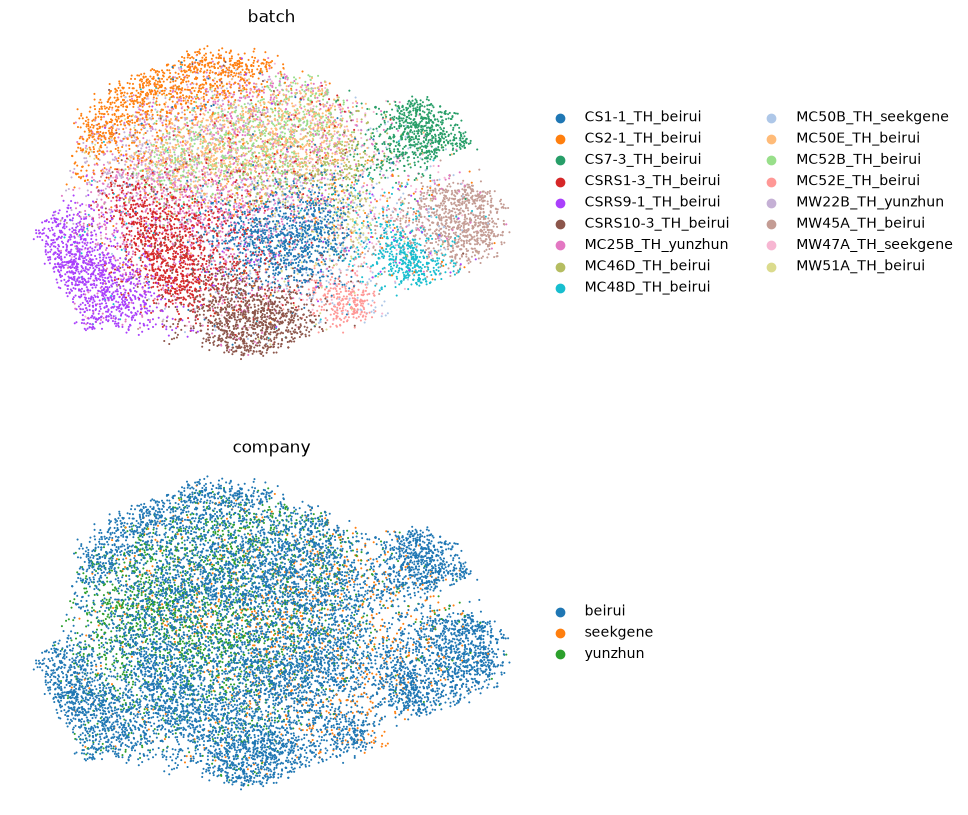

In [19]:
sc.tl.umap(adata_subset, min_dist=0.3,neighbors_key="neighbors")
sc.pl.umap(
    adata_subset,
    color=["batch","company", "leiden"],
    frameon=False,
    ncols=1,
)

In [20]:
# === 8. DEG 比较（CON 为共同对照组） ===
# status 共 5 类：CON / CURES / CUSUS / CSRES / CSSUS
# 命名约定：C=control stress / S=CSDS stress，末尾 R/S = Resilient / Susceptible
#
# 比较列表：
#   RES_vs_CON    : CURES vs CON        (对照+抗压 vs 对照)
#   SUS_vs_CON    : CUSUS vs CON        (对照+易感 vs 对照)
#   CSDS_vs_CON   : (CSRES ∪ CSSUS) vs CON
#   CSRES_vs_CON  : CSRES vs CON        (CSDS+抗压 vs 对照)

import pandas as pd
from scipy.stats import false_discovery_control

status = adata_subset.obs["status"].astype(str)
print("status counts:")
print(status.value_counts())

adata_de = adata_subset.copy()
adata_de.obs["status_3grp"] = np.where(
    status.isin(["CSRES", "CSSUS"]), "CSDS",
    np.where(status == "CON", "CON", status),
).astype(str)
print("\nstatus_3grp counts:")
print(adata_de.obs["status_3grp"].value_counts())

comparisons = [
    ("RES_vs_CON",    "status",      ["CURES"], "CON"),
    ("SUS_vs_CON",    "status",      ["CUSUS"], "CON"),
    ("CSDS_vs_CON",   "status_3grp", ["CSDS"],  "CON"),
    ("CSRES_vs_CON",  "status",      ["CSRES"], "CON"),
]

deg_results = {}
for label, gb, g1, g2 in comparisons:
    print(f"\n>>> {label}:  {g1} vs {g2}  (groupby={gb})")
    deg = model.differential_expression(
        adata=adata_de,
        groupby=gb,
        group1=g1,
        group2=g2,
        mode="change",
        delta=0.1,
        batch_correction=True,
        silent=False,
    )
    deg = deg.copy()
    deg.index.name = "gene"
    deg = deg.reset_index()
    deg["comparison"] = label
    deg["fdr"] = false_discovery_control(deg["proba_de"].values)
    deg_results[label] = deg

deg_all = pd.concat(deg_results.values(), ignore_index=True)
deg_all.to_csv(
    "/home/junyichen/code/RUVAEDEG/slide_figs/scvi_deg_4comparisons.csv",
    index=False,
)

summary = (
    deg_all.groupby("comparison")
    .agg(
        n_genes=("gene", "size"),
        n_de_fdr05=("fdr", lambda s: int((s < 0.05).sum())),
        n_up_lfc1=(
            "lfc_mean",
            lambda s: int(((deg_all.loc[s.index, "fdr"] < 0.05) & (s > 1)).sum()),
        ),
        n_down_lfc1=(
            "lfc_mean",
            lambda s: int(((deg_all.loc[s.index, "fdr"] < 0.05) & (s < -1)).sum()),
        ),
    )
)
print("\n=== DEG 摘要 ===")
print(summary)

status counts:

status
CSRES    3407
CUSUS    3049
CSSUS    2948
CON      2317
CURES    2164
Name: count, dtype: int64

status_3grp counts:

status_3grp
CSDS     6355
CUSUS    3049
CON      2317
CURES    2164
Name: count, dtype: int64

>>> RES_vs_CON:  ['CURES'] vs CON  (groupby=status)

...

DE...: 100%|██████████| 1/1 [00:09<00:00,  9.44s/it]


>>> CSRES_vs_CON:  ['CSRES'] vs CON  (groupby=status)

DE...: 100%|██████████| 1/1 [00:06<00:00,  6.65s/it]


=== DEG 摘要 ===

n_genes  n_de_fdr05  n_up_lfc1  n_down_lfc1
comparison                                               
CSDS_vs_CON     16428           0          0            0
CSRES_vs_CON    16428           0          0            0
RES_vs_CON      16428           0          0            0
SUS_vs_CON      16428           0          0            0

In [21]:
deg_all[deg_all.lfc_median.abs() > 0.1].group1.value_counts()

group1
CSRES    13217
CURES    12696
CSDS     12317
CUSUS    11717
Name: count, dtype: int64

In [22]:
batch_idx = model.adata_manager.get_from_registry("batch")
cont_cov = model.adata_manager.get_from_registry("extra_continuous_covs")
cont_cov = torch.as_tensor(
    pd.DataFrame(cont_cov).to_numpy(dtype=np.float32),
    device=next(model.module.parameters()).device,
)


In [33]:
adata_subset.obs['batch_idx'] = batch_idx

In [ ]:

batch_map = dict(zip(adata_subset.obs['company'].values, adata_subset.obs['batch_idx'].values))

In [47]:
batch_map

{'beirui': np.int8(0), 'seekgene': np.int8(1), 'yunzhun': np.int8(2)}

In [ ]:
X_norm = model.get_normalized_expression(
    lib_size=1e4, transform_batch="beirui"
)
adata_subset.layers["scvi_nrom_counts"] = X_norm

In [36]:
# === SCVI reconstruct counts（真·后验预测抽样） ===
import torch

# 1) 拿到 batch / cov 输入
# 2) 从后验预测分布 p(x_hat | x) 抽样 n_samples 次
n_samples = 1   # 每细胞 1 个 reconstruction sample
reconstructed = model.posterior_predictive_sample(
    adata=adata_subset,
    n_samples=n_samples,
    batch_size=512,
    transform_batch="beirui",
    silent=False,
)
# 返回 shape: (n_samples, n_cells, n_genes) → squeeze 到 (n_cells, n_genes)
reconstructed = np.asarray(reconstructed.todense())

print(f"reconstructed shape: {reconstructed.shape}  dtype={reconstructed.dtype}")
print(f"range: [{reconstructed.min()}, {reconstructed.max()}]  median={np.median(reconstructed):.2f}")
print(f"fraction non-zero: {(reconstructed > 0).mean():.3f}")

# 3) 写回 adata
adata_subset.layers["scvi_reconstructed_counts"] = reconstructed



Working...:   0%|          | 0/1 [00:00<?, ?it/s]

Working...: 100%|██████████| 1/1 [00:00<00:00, 299.00it/s]


reconstructed shape: (13885, 16428)  dtype=float32

range: [0.0, 3691.0]  median=0.00

fraction non-zero: 0.093

In [37]:
hkg_priority = [
    "Aars", "Sars",
    "Polr2a", "Polr2f",
    "Psmd6", "Psmd7", "Psma5",
    "Rer1", "Ipo8", "Pop4", "Pes1",
    "Oaz1",
    "Rpl13a", "Rpl27", "Rps13", "Rps20",
    "Hprt1", "Gusb", "Ppia", "Ywhaz"
]

candidate_negative_control_genes = [
    # 在大规模跨组织分析中相对稳定
    "Oaz1",
    "Rps13",
    "Rps20",
    "Rpl27",

    # 小鼠脑中报告相对稳定的基础基因
    "Aars",
    "Polr2f",
    "Psmd6",
    "Psmd7",
    "Psma5",

    # RNA加工、核质运输与基础细胞维护
    "Ipo8",
    "Pop4",
    "Pes1",
    "Rer1",

    # 可作为补充候选，但必须在本数据中验证
    "Rpl13a",
    "Cyc1",
    "Sdha",
    "Ubc"
]

hkg_priority = candidate_negative_control_genes + hkg_priority

HKG available: 22 / 23

shared color: vmin=1.00, vmax=1.00

✓ saved: slide_figs/scvi_hkg_recon_status.png

✓ saved: slide_figs/raw_status.png

/tmp/ipykernel_3983748/3902396964.py:68: ImplicitModificationWarning: Layer 'count_diff' should not be a np.matrix, use np.ndarray instead.
  adata_subset.layers["count_diff"] = adata_subset.layers["scvi_reconstructed_counts"] - adata_subset.layers["counts"]


✓ saved: slide_figs/count_diff.png

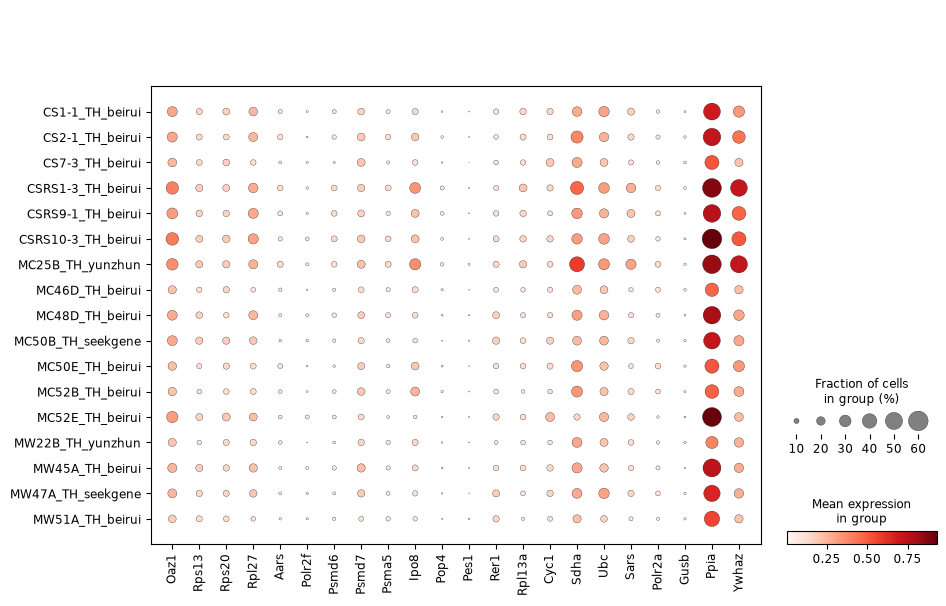

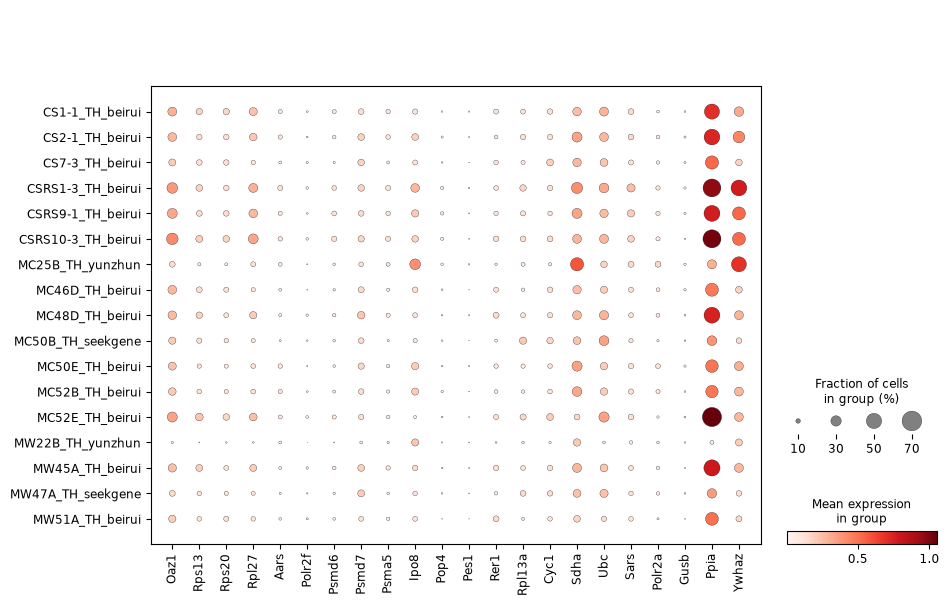

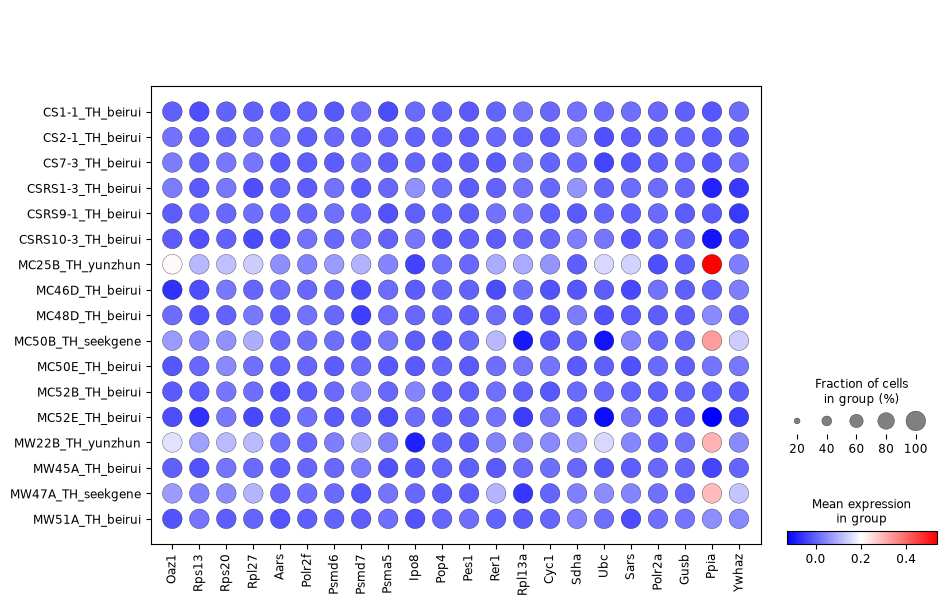

In [50]:
# ========== 9d. HKG dotplot: scvi_reconstructed_counts × status ==========
import scanpy as sc
import numpy as np

# 1) 准备 HKG 列表（保持 hkg_priority 顺序、去重、保留本数据中存在的）
seen = set()
hkg_genes = []
for g in hkg_priority:
    if g in adata_subset.var_names and g not in seen:
        seen.add(g)
        hkg_genes.append(g)
print(f"HKG available: {len(hkg_genes)} / {len(set(hkg_priority))}")

# 2) status 排序为 5 类固定顺序
adata_subset.obs["status"] = adata_subset.obs["status"].astype("category")
adata_subset.obs["status"] =adata_subset.obs["status"].cat.reorder_categories(
    ["CON", "CURES", "CUSUS", "CSRES", "CSSUS"]
)

# 3) 共享颜色尺度：把 reconstructed_counts 一起看，避免每 panel 自适应
recon = adata_subset.layers["scvi_reconstructed_counts"]
recon_arr = recon.toarray() if hasattr(recon, "toarray") else np.asarray(recon)
vmin = float(np.percentile(recon_arr[recon_arr > 0], 5))
vmax = float(np.percentile(recon_arr, 95))
print(f"shared color: vmin={vmin:.2f}, vmax={vmax:.2f}")

# 4) 画 dotplot — color = mean expr, size = % cells expressing
sc.settings.figdir = "/home/junyichen/code/RUVAEDEG/slide_figs"
fig = sc.pl.dotplot(
    adata_subset,
    var_names=hkg_genes,
    groupby="sample",
    layer="scvi_reconstructed_counts",
    cmap="Reds",
    standard_scale=None,     # 用真实 counts 量级，跨组可比
    swap_axes=False,
    dendrogram=False,
    return_fig=True,
    show=False,
    save="scvi_hkg_recon_status.png",
)
fig.savefig(
    "/home/junyichen/code/RUVAEDEG/slide_figs/scvi_hkg_recon_status.png",
    bbox_inches="tight", dpi=200,
)
print("✓ saved: slide_figs/scvi_hkg_recon_status.png")

sc.settings.figdir = "/home/junyichen/code/RUVAEDEG/slide_figs"
fig = sc.pl.dotplot(
    adata_subset,
    var_names=hkg_genes,
    groupby="sample",
    layer="counts",
    cmap="Reds",
    standard_scale=None,     # 用真实 counts 量级，跨组可比
    swap_axes=False,
    dendrogram=False,
    return_fig=True,
    show=False,
    save="raw_status.png",
)
fig.savefig(
    "/home/junyichen/code/RUVAEDEG/slide_figs/raw_status.png",
    bbox_inches="tight", dpi=200,
)
print("✓ saved: slide_figs/raw_status.png")

adata_subset.layers["count_diff"] = adata_subset.layers["scvi_reconstructed_counts"] - adata_subset.layers["counts"]
fig = sc.pl.dotplot(
    adata_subset,
    var_names=hkg_genes,
    groupby="sample",
    layer="count_diff",
    cmap="bwr",
    expression_cutoff=-1000,
    standard_scale=None,     # 用真实 counts 量级，跨组可比
    swap_axes=False,
    dendrogram=False,
    return_fig=True,
    show=False,
    save="raw_status.png",
)
fig.savefig(
    "/home/junyichen/code/RUVAEDEG/slide_figs/count_diff.png",
    bbox_inches="tight", dpi=200,
)
print("✓ saved: slide_figs/count_diff.png")

